In [1]:
# install requirements once
import pickle
import os
from mistralai import Mistral
import time
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
!pip install seaborn matplotlib
import requests

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [4]:
endpoint_url = "https://query.wikidata.org/sparql"
headers = {
    "Accept": "application/sparql-results+json"
}

query = """
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX wd: <http://www.wikidata.org/entity/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT ?event ?eventLabel ?date WHERE {
  SERVICE <https://query.wikidata.org/sparql> {
    ?event wdt:P585 ?date .
    
    FILTER(?date >= "1933-01-02T00:00:00Z"^^xsd:dateTime &&
           ?date <= "1933-12-31T23:59:59Z"^^xsd:dateTime)
           
    OPTIONAL {
      ?event rdfs:label ?eventLabel .
      FILTER(LANG(?eventLabel) = "de" || LANG(?eventLabel) = "en")
    }
  }
}
ORDER BY ?date
LIMIT 1000
"""

query = """
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX wd: <http://www.wikidata.org/entity/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT ?event ?eventLabel ?date WHERE {
  SERVICE <https://query.wikidata.org/sparql> {
    ?event wdt:P585 ?date .
    
    FILTER(?date >= "1938-01-02T00:00:00Z"^^xsd:dateTime &&
           ?date <= "1938-12-31T23:59:59Z"^^xsd:dateTime)

    # Ensure it's a historical event or subclass
    ?event wdt:P31/wdt:P279* wd:Q1656682 .
    
    # Filter for events in Germany and the German Reich
    FILTER(?country IN (wd:Q7318, wd:Q28108, wd:Q16957, wd:Q1198, wd:Q183, wd:Q1206012)) .
    ?event wdt:P17 ?country .


    OPTIONAL {
      ?event rdfs:label ?eventLabel .
      FILTER(LANG(?eventLabel) = "de" || LANG(?eventLabel) = "en")
    }
  }
}
ORDER BY ?date
LIMIT 100
"""

In [5]:
response = requests.get(endpoint_url, params={"query": query}, headers=headers)
if response.status_code != 200:
    print(f"Error {response.status_code}: {response.text}")
else:
    data = response.json()

    for item in data["results"]["bindings"]:
        print(item["event"]["value"], item.get("eventLabel", {}).get("value", ""), item["date"]["value"])


http://www.wikidata.org/entity/Q28154369 1937 Tschammerpokal Final 1938-01-09T00:00:00Z
http://www.wikidata.org/entity/Q670166 Eiskunstlauf-Weltmeisterschaft 1938 1938-02-01T00:00:00Z
http://www.wikidata.org/entity/Q670166 1938 World Figure Skating Championships 1938-02-01T00:00:00Z
http://www.wikidata.org/entity/Q447420 Reichstagswahl 1938 1938-04-10T00:00:00Z
http://www.wikidata.org/entity/Q447420 1938 German parliamentary election and referendum 1938-04-10T00:00:00Z
http://www.wikidata.org/entity/Q447420 Reichstagswahl 1938 1938-04-10T00:00:00Z
http://www.wikidata.org/entity/Q447420 1938 German parliamentary election and referendum 1938-04-10T00:00:00Z
http://www.wikidata.org/entity/Q447420 Reichstagswahl 1938 1938-04-10T00:00:00Z
http://www.wikidata.org/entity/Q447420 1938 German parliamentary election and referendum 1938-04-10T00:00:00Z
http://www.wikidata.org/entity/Q1532978 Septemberverschwörung 1938-09-01T00:00:00Z
http://www.wikidata.org/entity/Q1532978 Oster Conspiracy 1938-0

In [6]:
len(data["results"]["bindings"])

18

In [7]:
with open('merged_all_added_score.pkl', 'rb') as f:
    df = pickle.load(f)
df

,page_id,pagenumber,publication_date,place_of_distribution,language,plainpagefulltext,paper_title,score
0,UYPNVCGFNZRHE4VD4AV6LMBHODX7QDNA-FILE_0007_DDB...,7,1940-09-19 12:00:00,[Stuttgart],[ger],"fft, M — Schwäbischer Merkllr 3 Stuttgart — Do...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,1
1,5HNZ7CKJA23HRQVLH775UJINWQOLPLIT-FILE_0002_DDB...,2,1940-09-26 12:00:00,[Stuttgart],[ger],Nr. 226 — Schwäbischer Merkm Stuttgart — Donne...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
2,GTY6WLKCOIUQUTROD5AIF7YCHNQ25ITJ-FILE_0006_DDB...,6,1940-09-09 12:00:00,[Stuttgart],[ger],"8 Handelszeitung des Schwäbischen Merkur, Stut...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
3,JDRB3HLYATIXKFNZ4SY2IFFE6BI5SW6I-FILE_0005_DDB...,5,1940-09-18 12:00:00,[Stuttgart],[ger],"7 Schwäbischer Merkur (Schwäbische Kronik), St...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
4,VKUSW5DUFUGFJCRQOJJWQU4EQP4RSZWV-FILE_0004_DDB...,4,1940-09-16 12:00:00,[Stuttgart],[ger],"Nr. 217 — Schwäbischer Merkur Frage, bi« Mater...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,1
...,...,...,...,...,...,...,...,...
104031,OOYZ4LFEAKZJG6YIZB7VSYCKQYNIOKO2-FILE_0010_DDB...,10,1934-01-10 12:00:00,[Stuttgart],[ger],Nr. 6 — Seite 10 die Entwicklung der Vmeätxe l...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
104032,4M6YGR5JQA33FK62Q2UJNHILZQQHDC5G-FILE_0002_DDB...,2,1934-01-30 12:00:00,[Stuttgart],[ger],"SLllMWr Werter Dtmstag 30, Sanvar 1934 — Nr. z...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,2
104033,7ZFSURJJ5HU2VCOIJJII7NPLHUIVV5QW-FILE_0007_DDB...,7,1934-01-17 12:00:00,[Stuttgart],[ger],7 BiWöifdier Merkur und vom tt auch ein stille...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,1
104034,2MWQKNRRCYTBWSFYXYAXWGCIQMKDRRZG-FILE_0007_DDB...,7,1934-01-24 12:00:00,[Stuttgart],[ger],n 4 eWIfdjtr MerbU lebenribejahenLem Ginn« dur...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,0


In [8]:
df_tmp =df[df['score']!=""]
df_tmp['paper_title'].unique()


len(df)

25234

In [9]:
df_tmp = df[df['score'].astype(str).str.len() <= 5]
df_tmp_bigger = df[df['score'].astype(str).str.len() > 5]
len(df_tmp_bigger)

67

In [10]:
df_tmp = df_tmp[df_tmp['score'].isin(['1', '0', '-1', '2', '1.5', '-2','-1.6'])]
df_tmp['score'] = df_tmp['score'].astype(float)
#df_tmp = df_tmp[df_tmp['score']==0]

print(len(df_tmp[df_tmp['paper_title']=='Schwäbischer Merkur : mit Schwäbischer Kronik und Handelszeitung : Süddeutsche Zeitung']))
print(len(df_tmp[df_tmp['paper_title']=='Hamburger Tageblatt : Zeitung der Nationalsozialistischen Deutschen Arbeiterpartei']))
print(len(df_tmp[df_tmp['paper_title']=='Vorwärts']))

#len(df_filtered[df_filtered['paper_title']=='Schwäbischer Merkur : mit Schwäbischer Kronik und Handelszeitung : Süddeutsche Zeitung'])

11032
8031
6101


/var/folders/xt/zf0l90k91ks5gwsbsjtnkxr00000gn/T/ipykernel_53553/1635192763.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['score'] = df_tmp['score'].astype(float)
/var/folders/xt/zf0l90k91ks5gwsbsjtnkxr00000gn/T/ipykernel_53553/1635192763.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['publication_date'] = pd.to_datetime(df_tmp['publication_date'], errors='coerce')
/var/folders/xt/zf0l90k91ks5gwsbsjtnkxr00000gn/T/ipykernel_53553/1635192763.py:10: SettingWithCopyWarning: 
A value is 

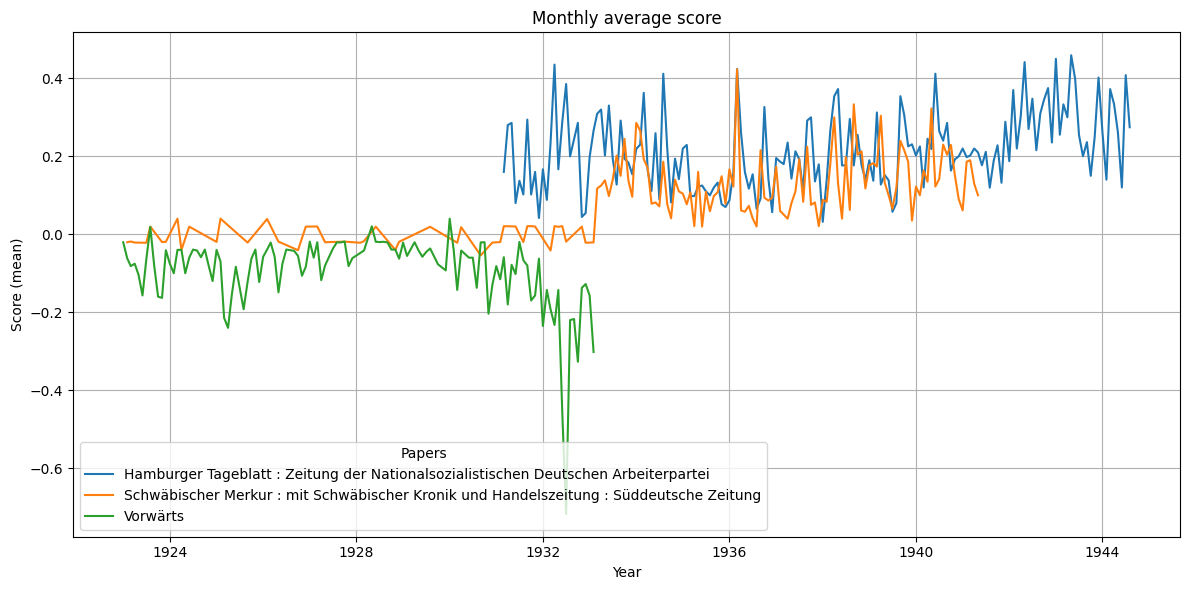

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter gültiger Scores
df_tmp = df[df['score'].isin(['1', '0', '-1', '2', '1.5', '-2','-1.6'])]
df_tmp['score'] = df_tmp['score'].astype(float)
df_tmp['publication_date'] = pd.to_datetime(df_tmp['publication_date'], errors='coerce')

# Gruppieren nach Titel, Woche und mittlerem Score
df_tmp['week'] = df_tmp['publication_date'].dt.to_period('M').dt.start_time

weekly_mean_scores = (
    df_tmp.groupby(['paper_title', 'week'])['score']
    .mean()
    .reset_index()
    .sort_values(by=['paper_title', 'week'])
)

# Nur Scores ≠ 0 plotten
score_grouped_tmp = weekly_mean_scores[weekly_mean_scores['score'] != 0]

# Plot
plt.figure(figsize=(12, 6))

for title in score_grouped_tmp['paper_title'].unique():
    df_paper = score_grouped_tmp[score_grouped_tmp['paper_title'] == title]
    plt.plot(df_paper['week'], df_paper['score'], label=title)

plt.title('Monthly average score')
plt.xlabel('Year')
plt.ylabel('Score (mean)')
plt.legend(title='Papers')
plt.grid(True)
plt.tight_layout()
plt.show()


Matched events at spike months:
1935-12-01: score=37.72 → <no event found>
1936-04-01: score=37.90 → <no event found>
1936-07-01: score=36.68 → <no event found>
1936-09-01: score=38.49 → <no event found>
1938-02-01: score=37.40 → Eiskunstlauf-Weltmeisterschaft 1938; 1938 World Figure Skating Championships
1944-07-01: score=38.04 → <no event found>
1927-02-01: score=36.92 → <no event found>


/var/folders/xt/zf0l90k91ks5gwsbsjtnkxr00000gn/T/ipykernel_53553/2625527273.py:102: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  events['month']       = events['date.value'].dt.to_period('M').dt.to_timestamp()


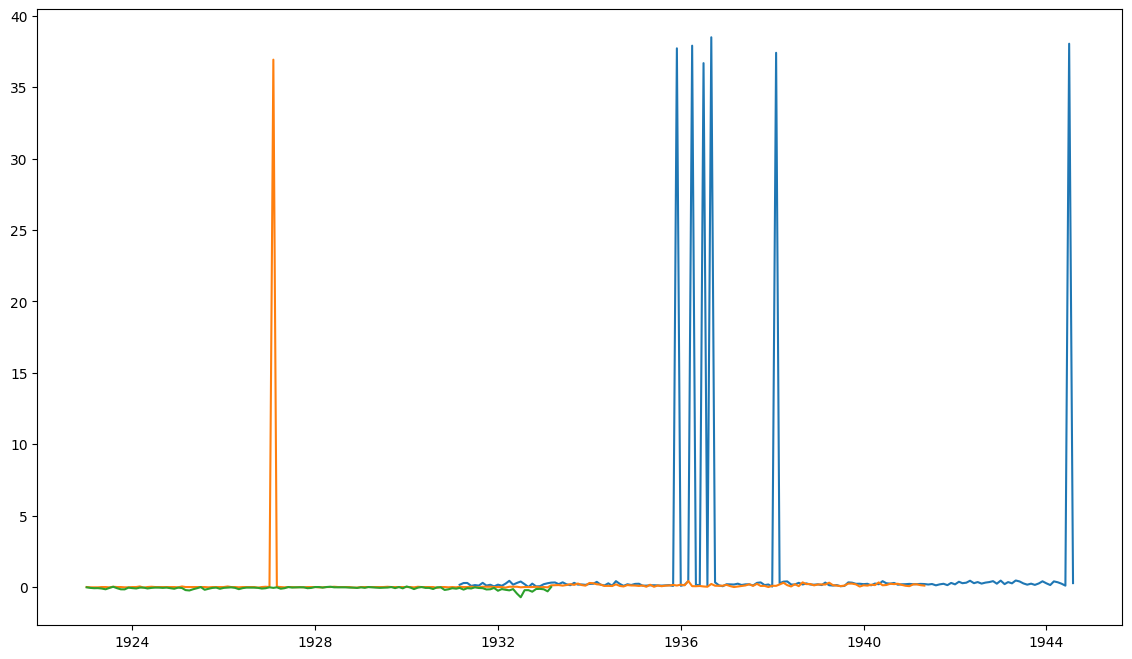

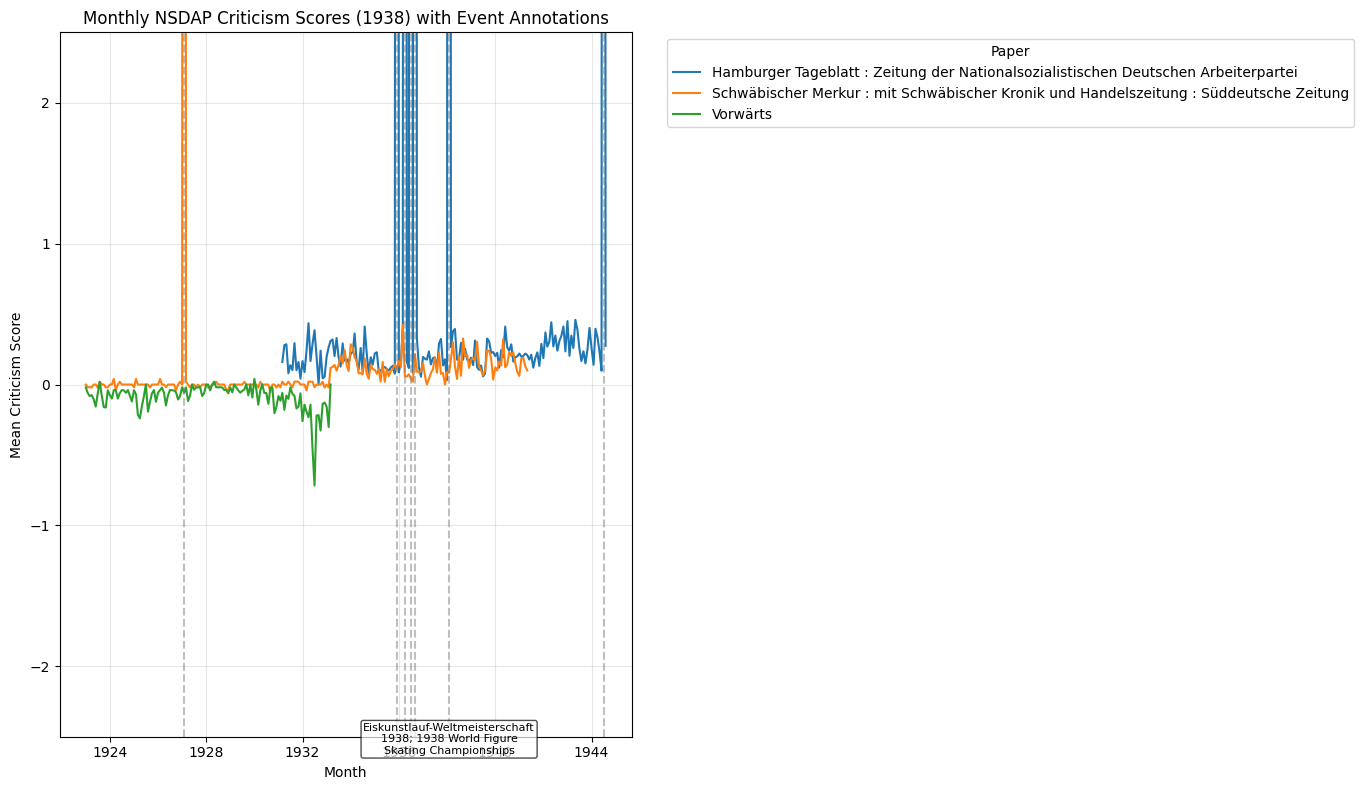

In [12]:
#%%
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import time
import textwrap

def fetch_sparql(endpoint, sparql, headers, timeout=60, max_retries=3, backoff=5):
    params = {"query": sparql}
    for attempt in range(1, max_retries+1):
        try:
            resp = requests.get(endpoint, params=params, headers=headers, timeout=timeout)
            resp.raise_for_status()
            return resp.json()
        except (requests.exceptions.ReadTimeout, requests.exceptions.ConnectionError) as e:
            if attempt == max_retries:
                raise
            print(f"Attempt {attempt} failed ({e!r}), retrying in {backoff}s…")
            time.sleep(backoff)
    # should never get here
    return None

def extract_first_number(s):
    """
    Given a string s, find the first occurrence of an integer or decimal number
    and return it as float. If none is found, return NaN.
    """
    if pd.isna(s):
        return float("nan")
    # look for integer or decimal, possibly signed
    m = re.search(r"[-+]?\d+(\.\d+)?", str(s))
    if m:
        return float(m.group(0))
    else:
        return float("nan")
    
# ——— 1) load & prep criticism data ———
df = pd.read_pickle("merged_all_added_score.pkl")

df["score"] = df["score"].apply(extract_first_number)
df = df.dropna(subset=["score"])

df['publication_date'] = pd.to_datetime(df['publication_date'], errors='coerce')
df['month'] = df['publication_date'].dt.to_period('M').dt.to_timestamp()

# compute monthly mean per paper
monthly = (
    df[df['score'].notna()]
    .groupby(['paper_title','month'])['score']
    .mean()
    .reset_index()
)

# pivot for easy plotting
papers = monthly['paper_title'].unique()

# overall mean & SD across all papers/months
mu, sigma = monthly['score'].mean(), monthly['score'].std()

# choose threshold, e.g. 1.5 sigma
threshold = 1.5 * sigma

# ——— 2) fetch Wikidata events for the same period ———
endpoint = "https://query.wikidata.org/sparql"
headers  = {"Accept":"application/sparql-results+json"}
start = monthly['month'].min().strftime("%Y-%m-%dT00:00:00Z")
end   = monthly['month'].max().strftime("%Y-%m-%dT23:59:59Z")
sparql = """
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX wd:   <http://www.wikidata.org/entity/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd:  <http://www.w3.org/2001/XMLSchema#>

SELECT ?eventLabel ?date WHERE {
  SERVICE <https://query.wikidata.org/sparql> {
    ?event wdt:P585 ?date .
    FILTER(
      ?date >= "1938-01-01T00:00:00Z"^^xsd:dateTime &&
      ?date <= "1938-12-31T23:59:59Z"^^xsd:dateTime
    )
    ?event wdt:P31/wdt:P279* wd:Q1656682 .
    ?event wdt:P17 ?country .
    FILTER(?country IN (
      wd:Q7318, wd:Q28108, wd:Q16957,
      wd:Q1198,  wd:Q183,   wd:Q1206012
    ))
    OPTIONAL {
      ?event rdfs:label ?eventLabel .
      FILTER(LANG(?eventLabel) IN ("de","en"))
    }
  }
}
ORDER BY ?date
LIMIT 500
"""
resp = requests.get(endpoint, params={"query":sparql}, headers=headers, timeout=30)
resp.raise_for_status()
data = fetch_sparql(endpoint_url, sparql, headers, timeout=60, max_retries=5, backoff=10)
bindings = data["results"]["bindings"]
events = pd.json_normalize(bindings)
events['date.value'] = pd.to_datetime(events['date.value'])
events['month']       = events['date.value'].dt.to_period('M').dt.to_timestamp()

# group event labels by month
events_by_month = (
    events.groupby('month')['eventLabel.value']
          .apply(lambda labels: "; ".join(labels.unique()))
          .to_dict()
)

# 3) plot & annotate spikes
plt.figure(figsize=(14,8))

for paper in papers:
    pm = monthly[monthly['paper_title']==paper]
    # correctly close the brackets and quotes here:
    plt.plot(pm['month'], pm['score'], label=paper)



# highlight spike months
spikes = (
    monthly.loc[
        (monthly['score'] - mu).abs() > threshold, 
        ['month','score']
    ]
    .drop_duplicates()
)

print("Matched events at spike months:")
for _, row in spikes.iterrows():
    month = row["month"]
    score = row["score"]
    label = events_by_month.get(month)
    if label:
        print(f"{month.date()}: score={score:.2f} → {label}")
    else:
        print(f"{month.date()}: score={score:.2f} → <no event found>")

# ——— 3b) Now plot & annotate as before ———
plt.figure(figsize=(14,8))
for paper in papers:
    pm = monthly[monthly["paper_title"] == paper]
    plt.plot(pm["month"], pm["score"], label=paper)

for _, row in spikes.iterrows():
    m, s = row["month"], row["score"]
    plt.axvline(m, color="gray", linestyle="--", alpha=0.5)
    label = events_by_month.get(m)
    if not label:
        continue
    wrapped = textwrap.fill(label, width=30)
    plt.text(
        m, -2.4, wrapped,
        rotation=0, ha="center", va="top",
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.2")
    )

plt.title("Monthly NSDAP Criticism Scores (1938) with Event Annotations")
plt.xlabel("Month")
plt.ylabel("Mean Criticism Score")
plt.ylim(-2.5, 2.5)
plt.legend(title="Paper", bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
#%%
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import time
import textwrap

def fetch_sparql(endpoint, sparql, headers, timeout=60, max_retries=3, backoff=5):
    params = {"query": sparql}
    for attempt in range(1, max_retries+1):
        try:
            resp = requests.get(endpoint, params=params, headers=headers, timeout=timeout)
            resp.raise_for_status()
            return resp.json()
        except (requests.exceptions.ReadTimeout, requests.exceptions.ConnectionError) as e:
            if attempt == max_retries:
                raise
            print(f"Attempt {attempt} failed ({e!r}), retrying in {backoff}s…")
            time.sleep(backoff)
    # should never get here
    return None

def extract_first_number(s):
    """
    Given a string s, find the first occurrence of an integer or decimal number
    and return it as float. If none is found, return NaN.
    """
    if pd.isna(s):
        return float("nan")
    # look for integer or decimal, possibly signed
    m = re.search(r"[-+]?\d+(\.\d+)?", str(s))
    if m:
        return float(m.group(0))
    else:
        return float("nan")
    
# ——— 1) load & prep criticism data ———
df = pd.read_pickle("merged_all_added_score.pkl")

df["score"] = df["score"].apply(extract_first_number)
df = df.dropna(subset=["score"])

df['publication_date'] = pd.to_datetime(df['publication_date'], errors='coerce')
df['month'] = df['publication_date'].dt.to_period('M').dt.to_timestamp()

# compute monthly mean per paper
monthly = (
    df[df['score'].notna()]
    .groupby(['paper_title','month'])['score']
    .mean()
    .reset_index()
)

# pivot for easy plotting
papers = monthly['paper_title'].unique()

# overall mean & SD across all papers/months
mu, sigma = monthly['score'].mean(), monthly['score'].std()

# choose threshold, e.g. 1.5 sigma
threshold = 1.5 * sigma

from dateutil.relativedelta import relativedelta

# determine your full time span
min_m = monthly['month'].min()
max_m = monthly['month'].max()

# SPARQL template; we'll fill in {start} / {end} for each month
sparql_template = """
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX wd:   <http://www.wikidata.org/entity/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd:  <http://www.w3.org/2001/XMLSchema#>

SELECT ?eventLabel ?date WHERE {{
    ?event wdt:P585 ?date .
    FILTER(
      ?date >= "{start}"^^xsd:dateTime &&
      ?date <= "{end}"^^xsd:dateTime
    )
    ?event wdt:P31/wdt:P279* wd:Q1656682 .
    ?event wdt:P17 ?country .
    FILTER(?country IN (
      wd:Q7318, wd:Q28108, wd:Q16957,
      wd:Q1198,  wd:Q183,   wd:Q1206012
    ))
    OPTIONAL {{
      ?event rdfs:label ?eventLabel .
      FILTER(LANG(?eventLabel) IN ("de","en"))
    }}
}}
ORDER BY ?date
LIMIT 500
"""

# iterate month by month
all_bindings = []
cursor = min_m
while cursor <= max_m:
    month_start = cursor
    month_end   = (cursor + relativedelta(months=1)) - pd.Timedelta(seconds=1)
    q = sparql_template.format(
        start = month_start.strftime("%Y-%m-%dT00:00:00Z"),
        end   = month_end.strftime("%Y-%m-%dT23:59:59Z")
    )

    try:
        js = fetch_sparql(
            endpoint="https://query.wikidata.org/sparql",
            sparql=q,
            headers=headers,
            timeout=20,
            max_retries=4,
            backoff=5
        )
    except Exception as e:
        print(f"Failed for {month_start:%Y-%m}: {e}")
    else:
        batch = js["results"]["bindings"]
        for b in batch:
            # annotate each binding with the month it came from
            b["_month"] = month_start
        all_bindings.extend(batch)

    cursor += relativedelta(months=1)

# now build your DataFrame exactly as before
events = pd.json_normalize(all_bindings)
events['date.value'] = pd.to_datetime(events['date.value'])
# prefer the explicit `_month` we injected
events['month']      = events['_month']

# group event labels by month
events_list_by_month = (
    events
    .groupby('month')['eventLabel.value']
    .apply(lambda labels: labels.dropna().unique().tolist())
    .to_dict()
)

# 3) plot & annotate spikes
plt.figure(figsize=(14,8))

for paper in papers:
    pm = monthly[monthly['paper_title']==paper]
    # correctly close the brackets and quotes here:
    plt.plot(pm['month'], pm['score'], label=paper)

events_list_by_month = (
    events
    .groupby('month')['eventLabel.value']
    .apply(lambda labels: labels.dropna().unique().tolist())
    .to_dict()
)

# highlight spike months
spikes = (
    monthly.loc[
        (monthly['score'] - mu).abs() > threshold, 
        ['month','score']
    ]
    .drop_duplicates()
)

print("Matched events at spike months:")
for _, row in spikes.iterrows():
    month, score = row['month'], row['score']
    labels = events_list_by_month.get(month, [])
    if labels:
        for lab in labels:
            print(f"{month.date()}: score={score:.2f} → {lab}")
    else:
        print(f"{month.date()}: score={score:.2f} → <no event found>")

# ——— 3b) Now plot & annotate as before ———
plt.figure(figsize=(14,8))
for paper in papers:
    pm = monthly[monthly["paper_title"] == paper]
    plt.plot(pm["month"], pm["score"], label=paper)

for _, row in spikes.iterrows():
    m, s = row["month"], row["score"]
    plt.axvline(m, color="gray", linestyle="--", alpha=0.5)
    label = events_by_month.get(m)
    if not label:
        continue
    text = textwrap.fill(" ; ".join(labels), width=30)
    plt.text(
        m, -2.4, text,
        rotation=0, ha="center", va="top",
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.2")
    )

plt.title("Monthly NSDAP Criticism Scores (1938) with Event Annotations")
plt.xlabel("Month")
plt.ylabel("Mean Criticism Score")
plt.ylim(-2.5, 2.5)
plt.legend(title="Paper", bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Attempt 1 failed (ReadTimeout(ReadTimeoutError("HTTPSConnectionPool(host='query.wikidata.org', port=443): Read timed out. (read timeout=20)"))), retrying in 5s…
Attempt 2 failed (ReadTimeout(ReadTimeoutError("HTTPSConnectionPool(host='query.wikidata.org', port=443): Read timed out. (read timeout=20)"))), retrying in 5s…
Attempt 3 failed (ReadTimeout(ReadTimeoutError("HTTPSConnectionPool(host='query.wikidata.org', port=443): Read timed out. (read timeout=20)"))), retrying in 5s…


KeyboardInterrupt: 

/var/folders/xt/zf0l90k91ks5gwsbsjtnkxr00000gn/T/ipykernel_53406/4119217894.py:77: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  events["month"]      = events["date.value"].dt.to_period("M").dt.to_timestamp()


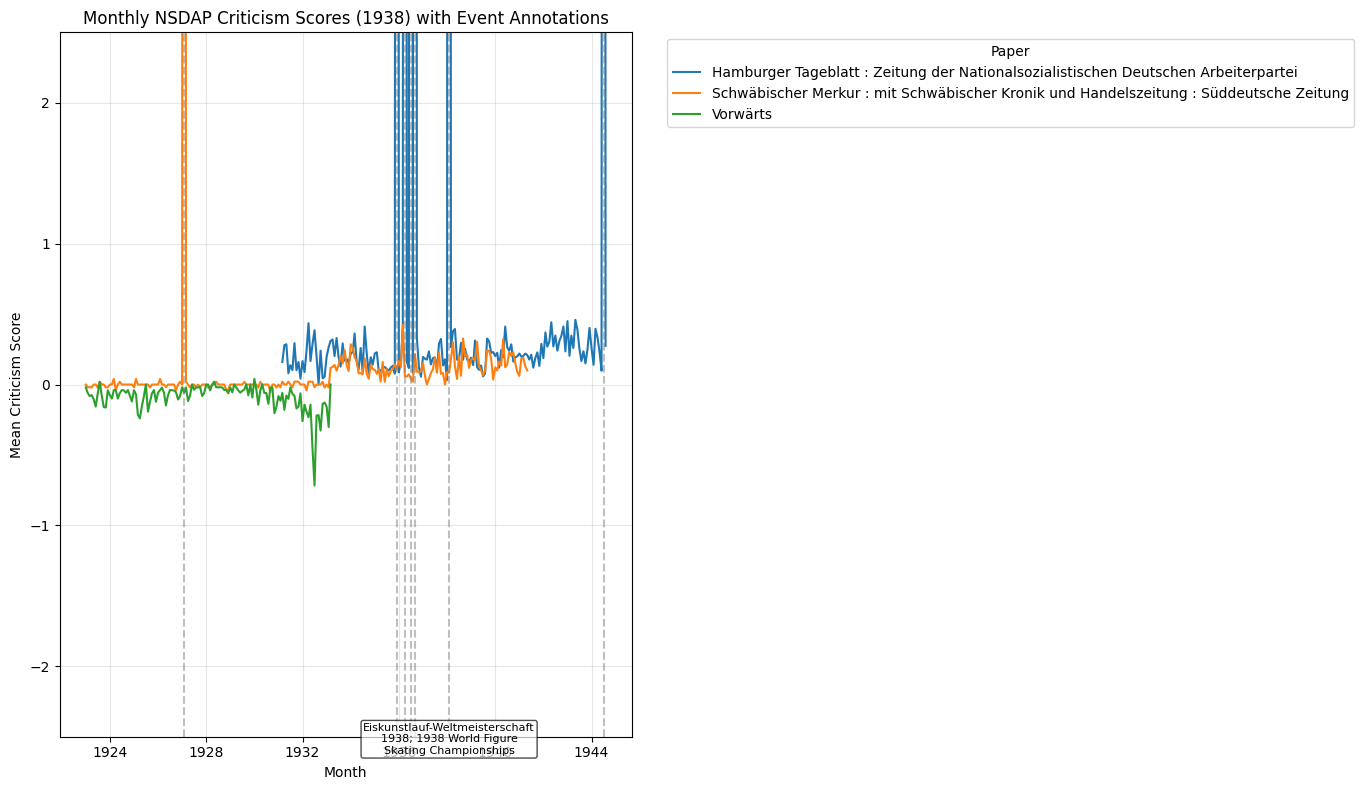

In [12]:
#%%
import requests, time, re, textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ——— helper to retry SPARQL ———
def fetch_sparql(endpoint, sparql, headers, timeout=60, max_retries=3, backoff=5):
    for attempt in range(1, max_retries+1):
        try:
            r = requests.get(endpoint, params={"query": sparql}, headers=headers, timeout=timeout)
            r.raise_for_status()
            return r.json()
        except (requests.exceptions.ReadTimeout, requests.exceptions.ConnectionError) as e:
            if attempt == max_retries:
                raise
            print(f"SPARQL attempt {attempt} failed, retrying in {backoff}s…")
            time.sleep(backoff)
    return None  # never actually reached

# ——— load & prepare criticism data ———
df = pd.read_pickle("merged_all_added_score.pkl")

# extract first numeric from score column
def first_number(s):
    m = re.search(r"[-+]?\d+(\.\d+)?", str(s))
    return float(m.group()) if m else np.nan

df["score"] = df["score"].apply(first_number)
df.dropna(subset=["score"], inplace=True)
df["publication_date"] = pd.to_datetime(df["publication_date"], errors="coerce")
df["month"] = df["publication_date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    df
    .groupby(["paper_title","month"])["score"]
    .mean()
    .reset_index()
)

# compute global mean & std, define spike threshold
μ, σ = monthly["score"].mean(), monthly["score"].std()
threshold = 1.5 * σ

# ——— fetch events ———
endpoint = "https://query.wikidata.org/sparql"
headers  = {"Accept": "application/sparql-results+json"}
sparql = """
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX wd:   <http://www.wikidata.org/entity/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd:  <http://www.w3.org/2001/XMLSchema#>

SELECT ?eventLabel ?date WHERE {
  SERVICE <https://query.wikidata.org/sparql> {
    ?event wdt:P585 ?date .
    FILTER(
      ?date >= "1938-01-01T00:00:00Z"^^xsd:dateTime &&
      ?date <= "1938-12-31T23:59:59Z"^^xsd:dateTime
    )
    ?event wdt:P31/wdt:P279* wd:Q1656682 ;
           wdt:P17  ?country .
    FILTER(?country IN ( wd:Q7318, wd:Q28108, wd:Q16957, wd:Q1198, wd:Q183, wd:Q1206012 ))
    OPTIONAL {
      ?event rdfs:label ?eventLabel .
      FILTER(LANG(?eventLabel) IN ("de","en"))
    }
  }
}
ORDER BY ?date
LIMIT 500
"""
res = fetch_sparql(endpoint, sparql, headers, timeout=30, max_retries=5)
bindings = res["results"]["bindings"]
events = pd.json_normalize(bindings)
events["date.value"] = pd.to_datetime(events["date.value"])
events["month"]      = events["date.value"].dt.to_period("M").dt.to_timestamp()

# group all labels by month
events_by_month = (
    events
    .groupby("month")["eventLabel.value"]
    .apply(lambda labs: "; ".join(dict.fromkeys(labs)))  # unique + preserve order
    .to_dict()
)

# ——— identify spike months ———
spikes = (
    monthly.loc[
      (monthly["score"] - μ).abs() > threshold,
      ["month","score"]
    ]
    .drop_duplicates(subset="month")
)

# ——— plot everything ———
plt.figure(figsize=(14,8))

# 1) plot each paper's time series
for paper in monthly["paper_title"].unique():
    dfp = monthly[monthly["paper_title"] == paper]
    plt.plot(dfp["month"], dfp["score"], label=paper)

# 2) annotate each spike
for _, row in spikes.iterrows():
    m = row["month"]
    # draw dashed vertical
    plt.axvline(m, color="gray", linestyle="--", alpha=0.5)
    # if we have an event label for that month:
    label = events_by_month.get(m)
    if not label:
        continue

    # wrap long text
    wrapped = textwrap.fill(label, width=30)

    # place horizontally below x-axis
    plt.text(
        m,               # x‐position
        -2.4,            # y‐position just below y‐min
        wrapped,
        rotation=0,
        ha="center",
        va="top",
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.2")
    )

# 3) finalize
plt.ylim(-2.5, 2.5)
plt.title("Monthly NSDAP Criticism Scores (1938) with Event Annotations")
plt.xlabel("Month")
plt.ylabel("Mean Criticism Score")
plt.legend(title="Paper", bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
